## UVA Analysis: Foreign Gifts 
Ciarra Barnett 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
gifts = pd.read_csv("ForeignGifts_edu.csv")
gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [47]:
uva= gifts[gifts["Institution Name"]==("University of Virginia")]
uva.head(5)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [24]:
uva_total = uva["Foreign Gift Amount"].sum()
uva_count = len(uva)
uva_mean = uva["Foreign Gift Amount"].mean()
uva_median = uva["Foreign Gift Amount"].median()

print(f"UVA Total Foreign Funding: {uva_total:,.2f}")
print(f"Number of UVA Gifts: {uva_count}")
print(f"UVA Average Gift: {uva_mean:,.2f}")
print(f"UVA Median Gift: {uva_median:,.2f}")



UVA Total Foreign Funding: 22,189,238.00
Number of UVA Gifts: 98
UVA Average Gift: 226,420.80
UVA Median Gift: 80,535.50


## UVA giving overview

The University of Virginia received around 22,189,238.00 in foreign funding across 98 gift records. The average gift was 226,420.80, the median gift was just about 80,535.50. 

In [17]:
uva_country_totals = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False)
)

uva_country_totals.head(10)

Country of Giftor
BANGLADESH     4228589
SWEDEN         4007552
TANZANIA       2776447
SWITZERLAND    2000000
ENGLAND        1950666
GUERNSEY       1500000
FINLAND        1008384
BERMUDA         900000
KOREA           862787
SINGAPORE       805000
Name: Foreign Gift Amount, dtype: int64

## UVA's largest foreign sources

Bangladesh and Sweden are UVA's two largest sources of foreign funding, each contributing around 4 million. Tanzania, Switzerland, and England are also important sources because they are each donating about 2 million or more. This show that UVA's foreign funding base is concentrated in a pretty small group of countries.

In [40]:
peer_names = ["University of Virginia","University of Michigan - Ann Arbor","University of California, Berkeley","Duke University", "University of North Carolina - Chapel Hill"]

peers = gifts[ gifts["Institution Name"].isin(peer_names)]
peers["Institution Name"].nunique()


5

In [44]:
peer_summary.columns = [
    "Institution",
    "Total Foreign Funding",
    "Number of Gifts",
    "Average Gift",
    "Median Gift"
]

peer_summary

,Institution,Total Foreign Funding,Number of Gifts,Average Gift,Median Gift
0,Duke University,343699498,145,2.370341e+06,566606.0
1,"University of California, Berkeley",294479904,394,7.474109e+05,424025.0
2,University of Michigan - Ann Arbor,287336783,715,4.018696e+05,200000.0
3,University of North Carolina - Chapel Hill,41292544,286,1.443795e+05,33548.0
4,University of Virginia,22189238,98,2.264208e+05,80535.5


## Peer institution comparison

To understand how UVA compares to similar universities, I compared UVA with Duke University, University of California Berkley, University of Michigan-Ann Arbor, University of North Carolina, Chapel Hill. 

I compared each university based on total foreign funding, number of gifts they receieved, average gift amount, and median gift amount. Duke received about 343.7 million, Berkeley received 294.5 million, Michigan received 287.3 million, and UNC received 41.3 million. UVA received 22.2 million

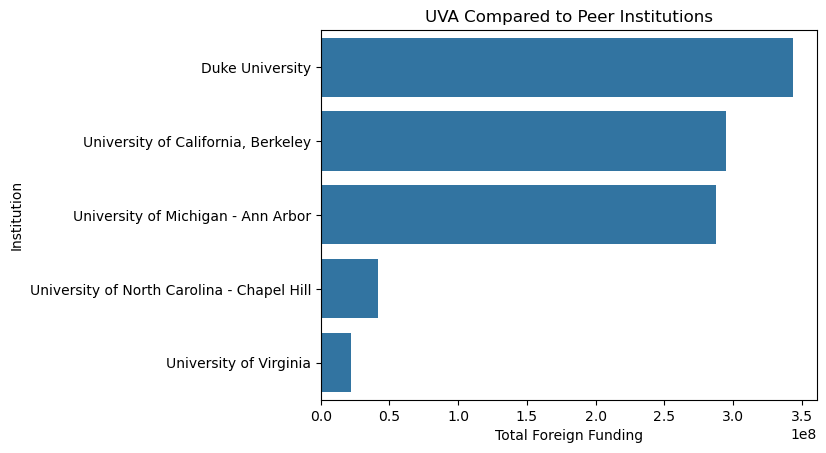

In [49]:
sns.barplot(
    data=peer_summary,
    x="Total Foreign Funding",
    y="Institution"
)

plt.title("UVA Compared to Peer Institutions")
plt.xlabel("Total Foreign Funding")
plt.ylabel("Institution")

plt.show()

## Market overall comparsion 
UVA received just about 22.2 million in total foreign funding ranking at 5th among the five peer institutions.  Duke University received the most foreign funding at 343.7 million, UC Berkeley at 294.5 million and the University of Michigan - Ann Arbor at 287.3 million. UNC - Chapel Hill received just about 41.3 million which is all higher than UVA foriegn funding. 

UVA also had 98 foreign gift records, the fewest among the selected peer institutions. UVA's average gift was approximately 226,421  while its median gift was about 80,536. Overall, UVA receives significantly less foreign funding than the selected peer institutions. This shows me that there is definitely more room to find international funding. 

In [55]:
peer_country_totals = (peers.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .sort_values(ascending=False))

peer_country_totals.head(10)

Country of Giftor
FRANCE         163665400
ENGLAND         94382546
SWEDEN          82695899
CHINA           70859363
SWITZERLAND     58640836
JAPAN           50188200
CANADA          43734288
KAZAKHSTAN      43533449
GERMANY         43466823
HONG KONG       37793106
Name: Foreign Gift Amount, dtype: int64

## Countries of giftor
 These are countries that give tons of money to UVA's peer instituions but give little to or nothing to UVA. 

In [66]:
opportunities = pd.DataFrame({ "Peer funding": peer_country_totals, "UVA funding": uva_country_totals }).fillna(0)
opportunities = opportunities.sort_values(
    "Peer funding",
    ascending=False
)

opportunities.head(15)


,Peer funding,UVA funding
Country of Giftor,,
FRANCE,163665400,250383.0
ENGLAND,94382546,1950666.0
SWEDEN,82695899,4007552.0
CHINA,70859363,0.0
SWITZERLAND,58640836,2000000.0
JAPAN,50188200,265970.0
CANADA,43734288,0.0
KAZAKHSTAN,43533449,0.0
GERMANY,43466823,0.0


In [69]:
new_sources = opportunities[
    opportunities["UVA funding"] == 0
]

new_sources.head(10)

,Peer funding,UVA funding
Country of Giftor,,
CHINA,70859363,0.0
CANADA,43734288,0.0
KAZAKHSTAN,43533449,0.0
GERMANY,43466823,0.0
HONG KONG,37793106,0.0
IRELAND,36703092,0.0
SAUDI ARABIA,29933342,0.0
DENMARK,22706096,0.0
TAIWAN,21371312,0.0


## Opportunities for funding 
This shows you which 10 largest foreign funding sources used by peer institutions that UVA currently receives $0 from. 

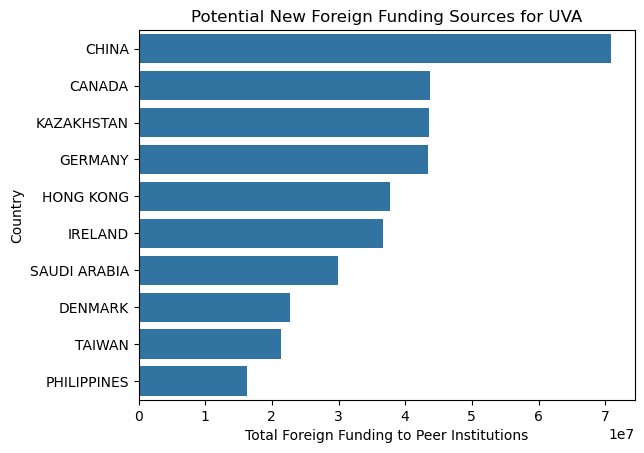

In [70]:
top_new_sources = new_sources.head(10).reset_index()

sns.barplot(
    data=top_new_sources,
    x="Peer funding",
    y="Country of Giftor"
)

plt.title("Potential New Foreign Funding Sources for UVA")
plt.xlabel("Total Foreign Funding to Peer Institutions")
plt.ylabel("Country")

plt.show()

## Strategy for increasing foreign funding

The analysis identified ten major international markets that provide plently of  funding to UVA's peer institutions but have no recorded funding to UVA in this dataset. Together, these countries provided just about 365 million to the selected peer group. China represents the largest opportunity at approximately 70.9 million, Canada at 43.7 million, Kazakhstan and Germanyat 43.5 million, and Hong Kong at 37.8 million.

UVA should focus on countries that already give large amounts of money to similar U.S. universities but give little or nothing to UVA. Countries like China, Canada, Germany, Hong Kong, and Ireland could provide new funding opportunities. UVA could look at who is funding its peer schools in these countries and find similar donors or organizations that could support UVA.

The quantitative results also suggest that UVA should focus on increasing the number of international funding relationships. UVA had only 98 foreign gift records compared with 145 at Duke, 394 at Berkeley, 715 at Michigan, and 286 at UNC. Because UVA's average gift was higher than UNC's despite receiving less total funding expanding the number of international donors and funding relationships may help UVA close part of the gap with its peers.